170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2444s 14us/step


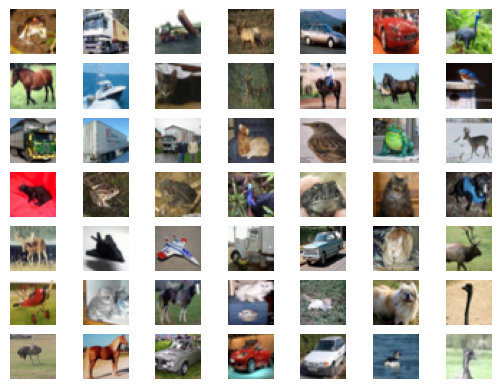

In [1]:
# ----------------------------------------
# Imports and Dataset Visualization
# ----------------------------------------

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')


from keras.datasets.cifar10 import load_data
from keras.models import Sequential
from keras.layers import (
    Dense,
    Conv2D,
    Conv2DTranspose,
    Flatten,
    Dropout,
    LeakyReLU,
    Reshape
)
from keras.optimizers import Adam

# Load CIFAR-10 datasset
(train_img,_),(_,_) = load_data()

# Display 49 real images
for i in range(49):
  plt.subplot(7,7,i+1)
  plt.axis('off')
  plt.imshow(train_img[i])

plt.show()

In [2]:
# ----------------------------------------
# Load and Normalize Dataset
# ----------------------------------------

def load_real_image():
  (train_img,_),(_,_) = load_data()
  imgs = train_img.astype("float32")
  imgs = (imgs - 127.5) / 127.5 # Normalize to [-1, 1]
  return imgs

# Load dataset
dataset = load_real_image()

# Use only 2000 images for faster training
dataset = dataset[:2000]
print(f"Dataset Shape:{dataset.shape}")

Dataset Shape:(2000, 32, 32, 3)


In [3]:
# ----------------------------------------
# Cell 3: Build Discriminator
# ----------------------------------------

def build_discriminator(input_shape=(32,32,3)):
  model = Sequential([
      # 32x32x3 → 32x32x64
      Conv2D(64,(3,3),padding='same',input_shape=input_shape),
      LeakyReLU(0.2),

      # 32x32x64 → 16x16x128
      Conv2D(128,(3,3),strides=(2,2),padding='same'),
      LeakyReLU(0.2),

      # 16x16x128 → 8x8x128
      Conv2D(128,(3,3),strides=(2,2),padding='same'),
      LeakyReLU(0.2),

      # 8x8x128 → 4x4x256
      Conv2D(256,(3,3),strides=(2,2),padding='same'),
      LeakyReLU(0.2),

      # # 4x4x256 → 4096
      Flatten(),

      # 4096 → 1
      Dense(1,activation='sigmoid')
   ])

  opt = Adam(learning_rate=0.0002,beta_1=0.5)

  model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['accuracy'])

  return model

discriminator = build_discriminator()
discriminator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ----------------------------------------
# Generate Real Samples
# ----------------------------------------

def get_real_samples(dataset,num_samples):
  indices = np.random.randint(0,dataset.shape[0],num_samples)
  images = dataset[indices]
  labels = np.ones((num_samples,1))
  return images,labels


In [5]:
# ----------------------------------------
# Generate Latent Points
# ----------------------------------------

def generate_latent_points(noise_dim,num_samples):
  noise = np.random.randn(num_samples,noise_dim)
  return noise

In [6]:
# ----------------------------------------
# Cell 6: Build Generator
# ----------------------------------------

def build_generator(noise_dim):
  model=Sequential(
      [
       # 100 → 4x4x256
        Dense(256 * 4 * 4, input_dim=noise_dim),
        LeakyReLU(0.2),

        Reshape((4, 4, 256)),

        # 4x4x256 → 8x8x128
        Conv2DTranspose(
            128,
            (4, 4),
            strides=(2, 2),
            padding="same"
        ),
        LeakyReLU(0.2),

        # 8x8x128 → 16x16x128
        Conv2DTranspose(
            128,
            (4, 4),
            strides=(2, 2),
            padding="same"
        ),
        LeakyReLU(0.2),

        # 16x16x128 → 32x32x128
        Conv2DTranspose(
            128,
            (4, 4),
            strides=(2, 2),
            padding="same"
        ),
        LeakyReLU(0.2),

        # 32x32x128 → 32x32x3
        Conv2D(
            3,
            (3, 3),
            activation="tanh",
            padding="same"
        )
    ])

  return model

noise_dim = 100
generator = build_generator(noise_dim)
generator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,115 (5.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ----------------------------------------
# Generate Fake Images
# ----------------------------------------

def generate_fake_image(generator,noise_dim,num_samples):

  noise = generate_latent_points(noise_dim,num_samples)
  img = generator.predict(noise,verbose=0)
  lbl = np.zeros((num_samples,1))
  return img,lbl

In [8]:
# ----------------------------------------
# Build GAN
# ----------------------------------------

def build_gan(generator,discriminator):
  discriminator.trainable = False

  model = Sequential([
      generator,discriminator
  ])
  opt = Adam(learning_rate=0.0002,beta_1=0.5)
  model.compile(loss='binary_crossentropy',optimizer=opt)
  return model


gan_model = build_gan(generator,discriminator)
gan_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │     1,466,115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 1)              │       522,497 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988,612 (7.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 522,497 (1.99 MB)

In [9]:
# ----------------------------------------
# Cell 9: GAN Training
# ----------------------------------------

def gan_training(generator,discriminator,gan_model,dataset,noise_dim,epochs=10,batch_size=128):
  # Number of batches in one epoch
  batches_per_epochs = dataset.shape[0]//batch_size
  # half batch for real and fake img
  half_batch = batch_size // 2

  for epoch in range(epochs):
    for batch in range(batches_per_epochs):

      # real image and label
      real_img,real_lbl = get_real_samples(dataset,half_batch)
      # fake image and label
      fake_img,fake_lbl = generate_fake_image(generator,noise_dim,half_batch)
      # Train Discriminator
      d_loss_real,_ = discriminator.train_on_batch(real_img,real_lbl)
      d_loss_fake,_ = discriminator.train_on_batch(fake_img,fake_lbl)
      # Train Generator
      noise = generate_latent_points(noise_dim,batch_size)
      # Generator wants Discriminator
      # to classify fake images as real
      generator_lbl = np.ones((batch_size,1))

      g_loss = gan_model.train_on_batch(noise,generator_lbl)

      print(
          f"Epoch {epoch+1}/{epochs},"
          f"Batch {batch+1}/{batches_per_epochs},"
          f"D_real={d_loss_real:.3f},"
          f"D_fake={d_loss_fake:.3f},"
          f"G={g_loss:.3f}"
      )
    print("-"*60)

In [11]:
# ----------------------------------------
# Train GAN
# ----------------------------------------
gan_training(
    generator = generator,
    discriminator = discriminator,
    gan_model = gan_model,
    dataset=dataset,
    noise_dim = noise_dim,
    epochs=10,
    batch_size = 128
)

Epoch 1/10,Batch 1/15,D_real=0.696,D_fake=0.695,G=0.693
Epoch 1/10,Batch 2/15,D_real=0.696,D_fake=0.696,G=0.693
Epoch 1/10,Batch 3/15,D_real=0.697,D_fake=0.696,G=0.692
Epoch 1/10,Batch 4/15,D_real=0.697,D_fake=0.697,G=0.692
Epoch 1/10,Batch 5/15,D_real=0.697,D_fake=0.697,G=0.691
Epoch 1/10,Batch 6/15,D_real=0.697,D_fake=0.698,G=0.690
Epoch 1/10,Batch 7/15,D_real=0.698,D_fake=0.698,G=0.689
Epoch 1/10,Batch 8/15,D_real=0.698,D_fake=0.699,G=0.688
Epoch 1/10,Batch 9/15,D_real=0.699,D_fake=0.700,G=0.685
Epoch 1/10,Batch 10/15,D_real=0.700,D_fake=0.702,G=0.683
Epoch 1/10,Batch 11/15,D_real=0.702,D_fake=0.704,G=0.679
Epoch 1/10,Batch 12/15,D_real=0.704,D_fake=0.706,G=0.675
Epoch 1/10,Batch 13/15,D_real=0.706,D_fake=0.709,G=0.670
Epoch 1/10,Batch 14/15,D_real=0.709,D_fake=0.712,G=0.664
Epoch 1/10,Batch 15/15,D_real=0.712,D_fake=0.715,G=0.658
------------------------------------------------------------
Epoch 2/10,Batch 1/15,D_real=0.715,D_fake=0.719,G=0.652
Epoch 2/10,Batch 2/15,D_real=0.718,D_

In [12]:
# ----------------------------------------
# Save Generated Images
# ----------------------------------------

def save_generated_img(images,epoch,n=7):
  # Convert [-1, 1] → [0, 1]
  img = (images+1)/2.0

  num_img = min(n*n,images.shape[0])

  for i in range(num_img):
    plt.subplot(n,n,i+1)
    plt.axis('off')
    plt.imshow[i]

  filename = f"generated_plot_e{epoch:.3d}.png"
  plt.savefig(filename)
  plt.close()

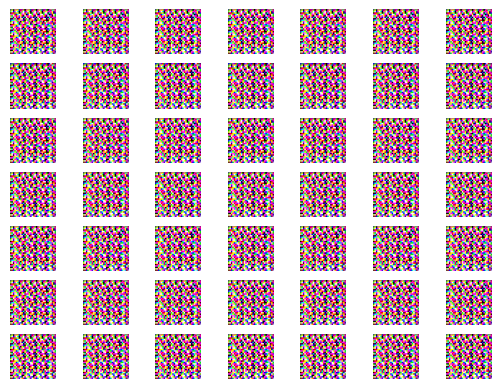

In [13]:
# ----------------------------------------
# Generate Images
# ----------------------------------------

latent_points = generate_latent_points(
    noise_dim=100,
    num_samples=100
)

generated_images = generator.predict(
    latent_points,
    verbose=0
)

# [-1, 1] → [0, 1]
generated_images = (generated_images + 1) / 2.0

# Display 49 generated images
for i in range(49):

    plt.subplot(7, 7, i + 1)
    plt.axis("off")
    plt.imshow(generated_images[i])

plt.show()